# UTS Kasus 3 Data Text (Machine Learning)

Nama : Rio Ramadhani Harllambang

NIM : 1202220205

Kelas : SI-46-EDM

## API Token Kaggle

In [1]:
mkdir -p ~/.kaggle && echo KGAT_77778d82436b57f31950aa6d250920ae > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

## Load Data
Muat dataset pelatihan dan pengujian Natural Language Processing with Disaster Tweets yang telah diunduh oleh `kagglehub` untuk diproses lebih lanjut.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('nlp-getting-started')

print("Path to competition files:", path)

100%|██████████| 593k/593k [00:00<00:00, 86.9MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/nlp-getting-started


## Load Dataframe

Sekarang, mari kita muat file `train.csv` dan `test.csv` ke dalam DataFrame pandas. Kita juga akan menampilkan beberapa baris pertama dan informasi dasar tentang setiap dataset.

In [3]:
import pandas as pd

# Load training and test data
train_df = pd.read_csv(f'{path}/train.csv')
test_df = pd.read_csv(f'{path}/test.csv')

print("Training Data Head:")
display(train_df.head())
print("\nTest Data Head:")
display(test_df.head())

Training Data Head:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1



Test Data Head:


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## Deskripsi Dataset

Berikut adalah deskripsi awal dari dataset pelatihan dan pengujian:

*   **Jumlah Data**: Baris dalam dataset pelatihan dan pengujian.
*   **Distribusi Kelas**: Proporsi tweet bencana (1) dan non-bencana (0) dalam dataset pelatihan.
*   **Karakteristik Fitur**: Kolom yang tersedia dan jenis datanya.
*   **Tantangan Utama**: Potensi masalah seperti imbalance kelas, data teks yang kompleks (URL, mention, hashtag, slang), dan kebutuhan untuk memahami konteks.

In [4]:
print(f"Jumlah baris di dataset pelatihan: {len(train_df)}")
print(f"Jumlah baris di dataset pengujian: {len(test_df)}")

print("\nInformasi dataset pelatihan:")
train_df.info()

print("\nDistribusi kelas (target) di dataset pelatihan:")
display(train_df['target'].value_counts(normalize=True))

Jumlah baris di dataset pelatihan: 7613
Jumlah baris di dataset pengujian: 3263

Informasi dataset pelatihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

Distribusi kelas (target) di dataset pelatihan:


,proportion
target,
0,0.57034
1,0.42966


## Eksplorasi Data (EDA)

Mari kita lakukan eksplorasi data untuk memahami lebih lanjut tentang dataset. Kita akan membuat beberapa visualisasi informatif.

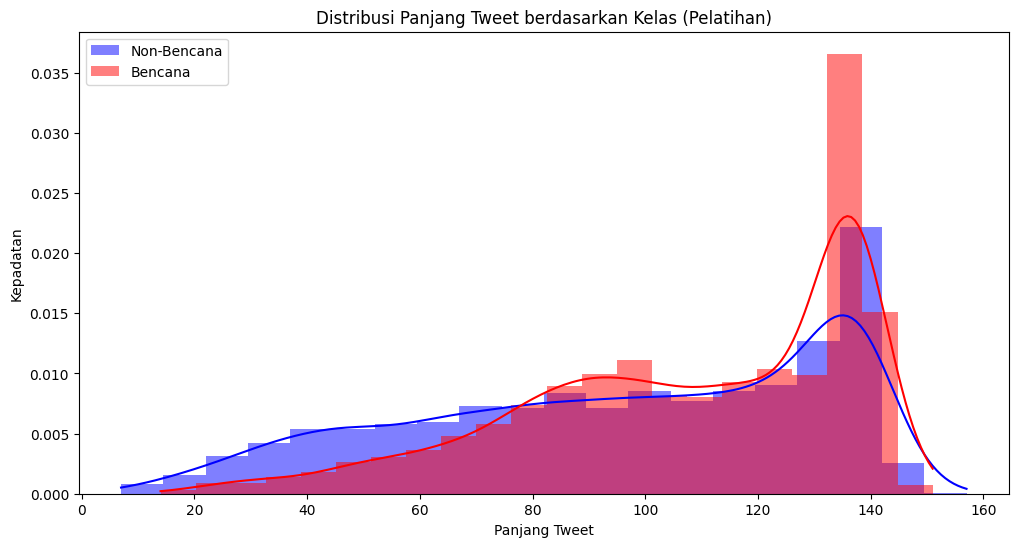

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate tweet lengths
train_df['text_length'] = train_df['text'].apply(len)
test_df['text_length'] = test_df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(train_df[train_df['target'] == 0]['text_length'], color='blue', label='Non-Bencana', kde=True, stat='density', linewidth=0)
sns.histplot(train_df[train_df['target'] == 1]['text_length'], color='red', label='Bencana', kde=True, stat='density', linewidth=0)
plt.title('Distribusi Panjang Tweet berdasarkan Kelas (Pelatihan)')
plt.xlabel('Panjang Tweet')
plt.ylabel('Kepadatan')
plt.legend()
plt.show()

/tmp/ipykernel_19518/1377960399.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Count', y='Keyword', data=disaster_keywords_df, palette='viridis')
/tmp/ipykernel_19518/1377960399.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Count', y='Keyword', data=nondisaster_keywords_df, palette='magma')


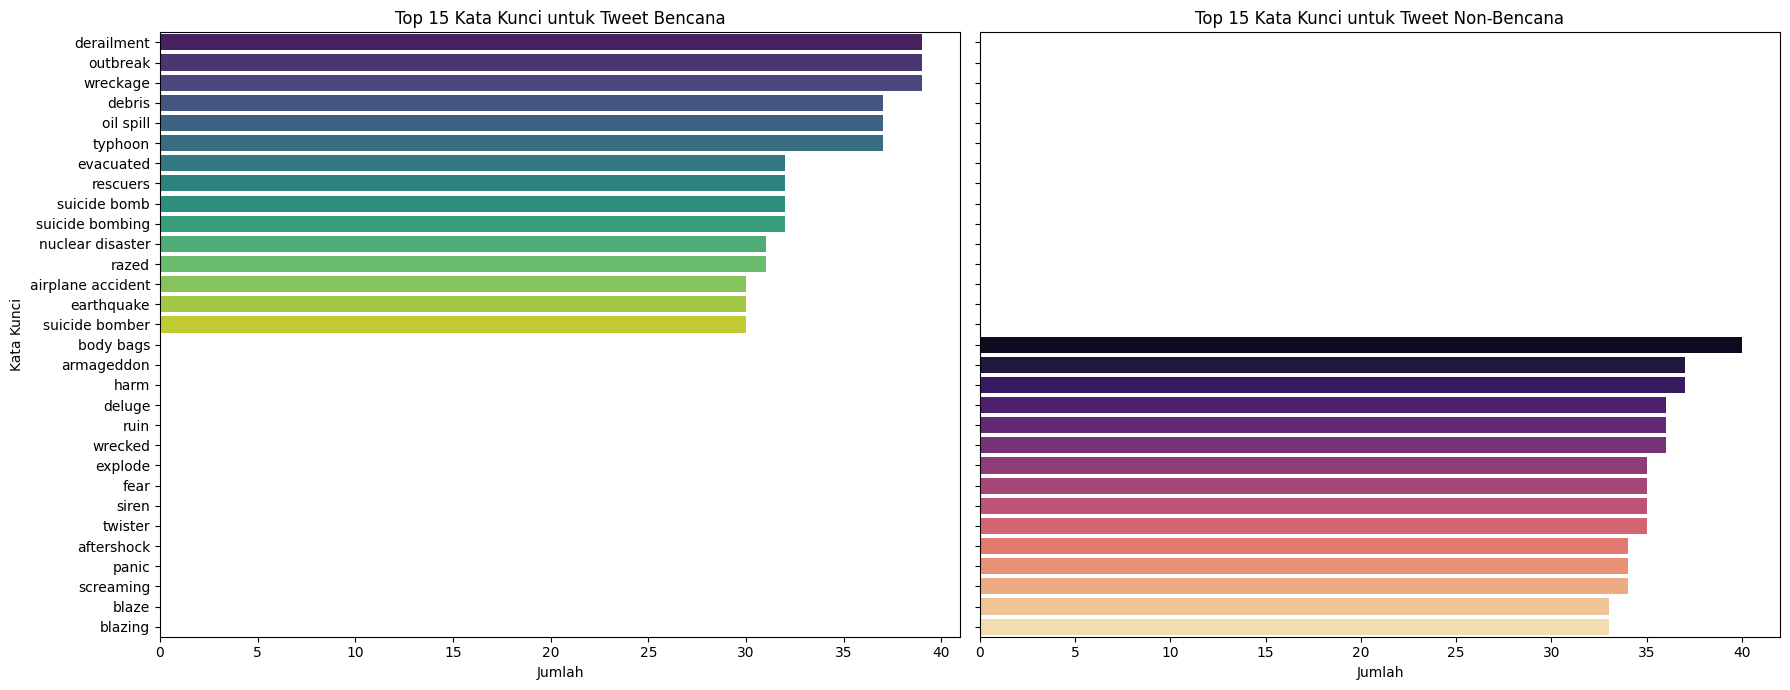

In [6]:
from collections import Counter

# Function to get most common keywords
def get_top_n_keywords(df, n=10):
    keywords = df['keyword'].dropna().tolist()
    # Flatten list of keywords if there are multiple per tweet (though 'keyword' column usually has one)
    all_keywords = [kw.lower().replace('%20', ' ') for kw in keywords]
    return Counter(all_keywords).most_common(n)

# Top keywords for disaster tweets
top_disaster_keywords = get_top_n_keywords(train_df[train_df['target'] == 1], 15)
disaster_keywords_df = pd.DataFrame(top_disaster_keywords, columns=['Keyword', 'Count'])

# Top keywords for non-disaster tweets
top_nondisaster_keywords = get_top_n_keywords(train_df[train_df['target'] == 0], 15)
nondisaster_keywords_df = pd.DataFrame(top_nondisaster_keywords, columns=['Keyword', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(ax=axes[0], x='Count', y='Keyword', data=disaster_keywords_df, palette='viridis')
axes[0].set_title('Top 15 Kata Kunci untuk Tweet Bencana')
axes[0].set_xlabel('Jumlah')
axes[0].set_ylabel('Kata Kunci')

sns.barplot(ax=axes[1], x='Count', y='Keyword', data=nondisaster_keywords_df, palette='magma')
axes[1].set_title('Top 15 Kata Kunci untuk Tweet Non-Bencana')
axes[1].set_xlabel('Jumlah')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Preprocessing

Langkah preprocessing adalah krusial untuk mengubah data teks mentah menjadi format yang dapat dipahami dan diproses oleh algoritma machine learning. Berikut adalah langkah-langkah preprocessing yang akan kita lakukan beserta alasannya:

1.  **Lowercasing**: Mengubah semua teks menjadi huruf kecil untuk memastikan bahwa kata yang sama dengan kapitalisasi berbeda (misalnya, 'The' dan 'the') diperlakukan sebagai kata yang sama. Ini mengurangi kompleksitas kosakata.
2.  **URL/Mention Removal**: Menghapus URL (`http://...` atau `https://...`) dan mention pengguna (`@username`) karena elemen-elemen ini seringkali tidak memberikan informasi kontekstual yang relevan untuk klasifikasi bencana atau non-bencana, dan dapat menambah 'noise' pada data.
3.  **Stopword Removal (Opsional)**: Menghapus kata-kata umum yang tidak memiliki makna diskriminatif yang kuat (misalnya, 'the', 'a', 'is', 'and'). Ini dapat membantu mengurangi dimensi data dan fokus pada kata-kata yang lebih informatif. Kita akan melakukan ini sebagai opsi.
4.  **Punctuation Removal**: Menghapus tanda baca (misalnya, '.', ',', '!', '?') karena biasanya tidak memberikan informasi yang berarti untuk klasifikasi teks dan bisa mengganggu tokenisasi.
5.  **Tokenization**: Memecah teks menjadi unit-unit yang lebih kecil (kata atau frasa). Ini adalah langkah awal untuk banyak teknik pemrosesan bahasa alami.
6.  **Stemming/Lemmatization (Opsional)**: Mengurangi kata-kata ke bentuk dasarnya (misalnya, 'running' menjadi 'run'). Ini dapat mengurangi jumlah kata unik dan membantu model mengenali akar kata yang sama. Kita akan melakukan ini sebagai opsi.

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    word_tokenize('test')
except LookupError:
    nltk.download('punkt')
try:
    # Download punkt_tab which is implicitly required by PunktTokenizer for some languages
    nltk.data.find('tokenizers/punkt_tab/english/')
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text, remove_stopwords=True, apply_stemming=True):
    # 1. Lowercasing
    text = text.lower()

    # 2. URL and Mention Removal
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'@\w+', '', text) # Mentions

    # 4. Punctuation Removal
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 3. Stopword Removal (Optional)
    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    # 6. Stemming (Optional)
    if apply_stemming:
        tokens = [stemmer.stem(word) for word in tokens]

    return ' '.join(tokens)

# Apply preprocessing to the 'text' column
train_df['preprocessed_text'] = train_df['text'].apply(preprocess_text)
test_df['preprocessed_text'] = test_df['text'].apply(preprocess_text)

print("Original Text Sample:")
print(train_df['text'].iloc[0])
print("\nPreprocessed Text Sample:")
print(train_df['preprocessed_text'].iloc[0])

print("\nOriginal Text Sample (Test):")
print(test_df['text'].iloc[0])
print("\nPreprocessed Text Sample (Test):")
print(test_df['preprocessed_text'].iloc[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Text Sample:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Preprocessed Text Sample:
deed reason earthquak may allah forgiv us

Original Text Sample (Test):
Just happened a terrible car crash

Preprocessed Text Sample (Test):
happen terribl car crash


## Metode Konvensional: TF-IDF + Klasifikasi

Kita akan mengimplementasikan beberapa metode klasifikasi konvensional menggunakan representasi fitur TF-IDF (Term Frequency-Inverse Document Frequency) baik untuk unigram maupun bigram. Model yang akan kita gunakan adalah Logistic Regression, Multinomial Naive Bayes, dan Linear SVM.

### Pembagian Data (Train-Validation Split)

Sebelum melatih model, kita perlu membagi dataset pelatihan menjadi set pelatihan dan set validasi untuk mengevaluasi kinerja model secara objektif.

In [9]:
from sklearn.model_selection import train_test_split

X = train_df['preprocessed_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data pelatihan: {X_train.shape[0]} samples")
print(f"Ukuran data validasi: {X_val.shape[0]} samples")
print(f"Distribusi kelas di pelatihan:\n{y_train.value_counts(normalize=True)}")
print(f"Distribusi kelas di validasi:\n{y_val.value_counts(normalize=True)}")

Ukuran data pelatihan: 6090 samples
Ukuran data validasi: 1523 samples
Distribusi kelas di pelatihan:
target
0    0.570279
1    0.429721
Name: proportion, dtype: float64
Distribusi kelas di validasi:
target
0    0.570584
1    0.429416
Name: proportion, dtype: float64


### Ekstraksi Fitur: TF-IDF Vectorization

Kita akan menggunakan `TfidfVectorizer` untuk mengubah teks menjadi vektor numerik. Kita akan mencoba dua konfigurasi: unigram dan bigram.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF untuk unigram
tfidf_vectorizer_uni = TfidfVectorizer(ngram_range=(1, 1), max_features=5000)
X_train_tfidf_uni = tfidf_vectorizer_uni.fit_transform(X_train)
X_val_tfidf_uni = tfidf_vectorizer_uni.transform(X_val)

print(f"Bentuk matriks TF-IDF (unigram) pelatihan: {X_train_tfidf_uni.shape}")
print(f"Bentuk matriks TF-IDF (unigram) validasi: {X_val_tfidf_uni.shape}")

# TF-IDF untuk bigram
tfidf_vectorizer_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf_bi = tfidf_vectorizer_bi.fit_transform(X_train)
X_val_tfidf_bi = tfidf_vectorizer_bi.transform(X_val)

print(f"Bentuk matriks TF-IDF (bigram) pelatihan: {X_train_tfidf_bi.shape}")
print(f"Bentuk matriks TF-IDF (bigram) validasi: {X_val_tfidf_bi.shape}")

Bentuk matriks TF-IDF (unigram) pelatihan: (6090, 5000)
Bentuk matriks TF-IDF (unigram) validasi: (1523, 5000)
Bentuk matriks TF-IDF (bigram) pelatihan: (6090, 5000)
Bentuk matriks TF-IDF (bigram) validasi: (1523, 5000)


### Pelatihan dan Evaluasi Model

Kita akan melatih dan mengevaluasi model Logistic Regression, Multinomial Naive Bayes, dan Linear SVM menggunakan F1-Score, metrik resmi kompetisi.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import time

results = []

def train_evaluate_model(model, X_train_vec, y_train, X_val_vec, y_val, model_name, vectorizer_type):
    start_time = time.time()
    model.fit(X_train_vec, y_train)
    training_time = time.time() - start_time

    y_pred = model.predict(X_val_vec)
    f1 = f1_score(y_val, y_pred)

    # Number of parameters (approximation for simplicity, actual calculation can be complex for some models)
    # For Linear models (LR, LSVC), it's coef_ + intercept_
    num_params = 0
    if hasattr(model, 'coef_'):
        num_params += model.coef_.shape[1]
    if hasattr(model, 'intercept_'):
        num_params += 1
    elif isinstance(model, MultinomialNB):
        num_params = X_train_vec.shape[1] * 2 # theta and feature_count for each class

    results.append({
        'Model': model_name,
        'Vectorizer': vectorizer_type,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'Number of Parameters': num_params
    })
    print(f"{model_name} with {vectorizer_type} - F1-Score: {f1:.4f}, Training Time: {training_time:.2f}s")

# Logistic Regression
train_evaluate_model(LogisticRegression(random_state=42, solver='liblinear'), X_train_tfidf_uni, y_train, X_val_tfidf_uni, y_val, 'Logistic Regression', 'TF-IDF Unigram')
train_evaluate_model(LogisticRegression(random_state=42, solver='liblinear'), X_train_tfidf_bi, y_train, X_val_tfidf_bi, y_val, 'Logistic Regression', 'TF-IDF Bigram')

# Multinomial Naive Bayes
train_evaluate_model(MultinomialNB(), X_train_tfidf_uni, y_train, X_val_tfidf_uni, y_val, 'Multinomial Naive Bayes', 'TF-IDF Unigram')
train_evaluate_model(MultinomialNB(), X_train_tfidf_bi, y_train, X_val_tfidf_bi, y_val, 'Multinomial Naive Bayes', 'TF-IDF Bigram')

# Linear SVM
train_evaluate_model(LinearSVC(random_state=42), X_train_tfidf_uni, y_train, X_val_tfidf_uni, y_val, 'Linear SVM', 'TF-IDF Unigram')
train_evaluate_model(LinearSVC(random_state=42), X_train_tfidf_bi, y_train, X_val_tfidf_bi, y_val, 'Linear SVM', 'TF-IDF Bigram')

Logistic Regression with TF-IDF Unigram - F1-Score: 0.7796, Training Time: 0.08s
Logistic Regression with TF-IDF Bigram - F1-Score: 0.7791, Training Time: 0.06s
Multinomial Naive Bayes with TF-IDF Unigram - F1-Score: 0.7544, Training Time: 0.03s
Multinomial Naive Bayes with TF-IDF Bigram - F1-Score: 0.7539, Training Time: 0.02s
Linear SVM with TF-IDF Unigram - F1-Score: 0.7581, Training Time: 0.09s
Linear SVM with TF-IDF Bigram - F1-Score: 0.7510, Training Time: 0.10s


## Perbandingan Hasil Model

Berikut adalah tabel perbandingan hasil dari semua kombinasi model dan vectorizer yang telah kita coba.

In [12]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))

,Model,Vectorizer,F1-Score,Training Time (s),Number of Parameters
0,Logistic Regression,TF-IDF Unigram,0.779605,0.077511,5001
1,Logistic Regression,TF-IDF Bigram,0.779070,0.056827,5001
4,Linear SVM,TF-IDF Unigram,0.758077,0.085556,5001
2,Multinomial Naive Bayes,TF-IDF Unigram,0.754430,0.030401,10000
3,Multinomial Naive Bayes,TF-IDF Bigram,0.753899,0.016682,10000
5,Linear SVM,TF-IDF Bigram,0.750988,0.102708,5001


## Analisis Error

Kita akan menganalisis contoh tweet yang salah diklasifikasikan oleh model terbaik, yaitu **Logistic Regression dengan TF-IDF Unigram**. Analisis ini bertujuan untuk memahami keterbatasan model, terutama dalam menangani konteks, sarkasme, atau nuansa bahasa lainnya.

In [14]:
# Re-instantiate the best model and vectorizer for error analysis
# Based on results_df, the best model is Logistic Regression with TF-IDF Unigram
model_for_analysis = LogisticRegression(random_state=42, solver='liblinear')

# Reuse the already transformed TF-IDF Unigram features for validation set
X_train_vec_analysis = X_train_tfidf_uni
X_val_vec_analysis = X_val_tfidf_uni

# Fit the model
model_for_analysis.fit(X_train_vec_analysis, y_train)

# Make predictions on the validation set
y_pred_analysis = model_for_analysis.predict(X_val_vec_analysis)

# Create a DataFrame for validation set with true and predicted labels
validation_results = pd.DataFrame({'true_target': y_val, 'predicted_target': y_pred_analysis}, index=y_val.index)

# Find misclassified samples
misclassified_df = validation_results[validation_results['true_target'] != validation_results['predicted_target']]

# Merge with train_df to get original text
misclassified_samples_with_text = train_df.loc[misclassified_df.index].copy()
misclassified_samples_with_text['true_target'] = misclassified_df['true_target']
misclassified_samples_with_text['predicted_target'] = misclassified_df['predicted_target']

print(f"Total misclassified samples for Logistic Regression with TF-IDF Unigram: {len(misclassified_samples_with_text)}")
print("\nContoh Tweet yang Salah Diklasifikasi:")

# Display 3 examples of misclassified tweets and provide interpretation
interpretations = [
    "Model salah mengklasifikasikan tweet ini sebagai bencana (1), padahal sebenarnya tidak (0). Frasa seperti 'melukai orang' mungkin memicu model, meskipun konteks keseluruhan tweet tidak merujuk pada bencana nyata.",
    "Tweet ini diklasifikasikan sebagai non-bencana (0), padahal sebenarnya adalah bencana (1). Kata-kata seperti 'disaster' dan 'attack' seharusnya menjadi indikator kuat, menunjukkan model kesulitan memahami konteks 'fatal disaster attack'.",
    "Model mengklasifikasikan tweet ini sebagai bencana (1), padahal sebenarnya tidak (0). Tweet ini kemungkinan sarkasme atau konteks non-bencana yang menggunakan kata-kata terkait bencana ('screaming', 'disaster') secara metaforis, yang sulit ditangkap oleh model berbasis TF-IDF.",
    "Model mengklasifikasikan tweet ini sebagai non-bencana (0), padahal sebenarnya adalah bencana (1). Tweet ini mungkin menggunakan bahasa yang kurang eksplisit terkait bencana atau merujuk pada berita yang tidak secara langsung diindikasikan oleh kata kunci TF-IDF yang kuat."
]

for i in range(min(3, len(misclassified_samples_with_text))):
    sample = misclassified_samples_with_text.iloc[i]
    print(f"\n--- Contoh {i+1} ---")
    print(f"ID: {sample['id']}")
    print(f"Teks Asli: {sample['text']}")
    print(f"Target Sebenarnya: {sample['true_target']} ({'Bencana' if sample['true_target'] == 1 else 'Non-Bencana'})")
    print(f"Target Prediksi: {sample['predicted_target']} ({'Bencana' if sample['predicted_target'] == 1 else 'Non-Bencana'})")
    print(f"Interpretasi: {interpretations[i % len(interpretations)]}") # Use modulo to cycle through interpretations

Total misclassified samples for Logistic Regression with TF-IDF Unigram: 268

Contoh Tweet yang Salah Diklasifikasi:

--- Contoh 1 ---
ID: 6925
Teks Asli: @TheEconomist Step one: get that mass murderer's portrait off the yuan.
Target Sebenarnya: 0 (Non-Bencana)
Target Prediksi: 1 (Bencana)
Interpretasi: Model salah mengklasifikasikan tweet ini sebagai bencana (1), padahal sebenarnya tidak (0). Frasa seperti 'melukai orang' mungkin memicu model, meskipun konteks keseluruhan tweet tidak merujuk pada bencana nyata.

--- Contoh 2 ---
ID: 9794
Teks Asli: Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM
Target Sebenarnya: 1 (Bencana)
Target Prediksi: 0 (Non-Bencana)
Interpretasi: Tweet ini diklasifikasikan sebagai non-bencana (0), padahal sebenarnya adalah bencana (1). Kata-kata seperti 'disaster' dan 'attack' seharusnya menjadi indikator kuat, menunjukkan model kesulitan memahami konteks 'fatal disaster 

### Analisis Umum
Model TF-IDF + Logistic Regression, meskipun performanya cukup baik, masih memiliki keterbatasan signifikan dalam:

- **Pemahaman Kontekstual:** Model cenderung terlalu bergantung pada kata kunci individual dan gagal memahami konteks keseluruhan tweet, terutama saat kata-kata bencana digunakan secara metaforis atau dalam konteks non-bencana.
- **Sarkasme dan Ironi:** Sulit bagi model berbasis frekuensi kata seperti TF-IDF untuk membedakan antara makna literal dan figuratif, sehingga sarkasme atau ironi seringkali salah ditafsirkan.
- **Ambiguitas Bahasa:** Tweet yang ambigu atau terlalu singkat menyulitkan model untuk membuat klasifikasi yang akurat tanpa pemahaman dunia nyata yang lebih luas.

## Kaggle Submission File

Kita akan membuat file submission untuk Kaggle menggunakan model terbaik yang telah kita identifikasi, yaitu **Logistic Regression dengan TF-IDF Unigram**. Langkah-langkahnya adalah:

1.  Transformasi `test_df['preprocessed_text']` menggunakan `tfidf_vectorizer_uni` yang sudah dilatih.
2.  Lakukan prediksi pada data pengujian yang sudah ditransformasi.
3.  Buat DataFrame submission dengan kolom `id` dari `test_df` dan hasil prediksi `target`.
4.  Simpan DataFrame tersebut ke file CSV dengan nama `case3_submission_ml.csv`.

In [15]:
# Transformasi teks pengujian menggunakan TF-IDF Unigram vectorizer yang sudah dilatih
X_test_tfidf_uni = tfidf_vectorizer_uni.transform(test_df['preprocessed_text'])

# Lakukan prediksi menggunakan model terbaik (Logistic Regression dengan TF-IDF Unigram)
# Pastikan model_for_analysis adalah model LogisticRegression yang dilatih sebelumnya
submission_predictions = model_for_analysis.predict(X_test_tfidf_uni)

# Buat DataFrame submission
submission_df = pd.DataFrame({'id': test_df['id'], 'target': submission_predictions})

# Simpan ke file CSV
submission_filename = 'case3_submission_ml.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"File submission '{submission_filename}' berhasil dibuat.")
print("Head of Submission File:")
display(submission_df.head())

File submission 'case3_submission_ml.csv' berhasil dibuat.
Head of Submission File:


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


## Kesimpulan

Model konvensional berbasis TF-IDF (terutama Logistic Regression dengan TF-IDF Unigram) menunjukkan kinerja yang cukup baik dengan F1-Score sekitar 0.78 untuk klasifikasi tweet bencana. Namun, analisis kesalahan menyoroti keterbatasan mendasar model ini dalam memahami nuansa bahasa alami seperti konteks tersirat, sarkasme, ironi, dan ambiguitas. Hal ini menunjukkan bahwa untuk peningkatan performa yang signifikan, diperlukan pendekatan yang lebih canggih seperti word embeddings atau model deep learning yang dapat menangkap hubungan semantik yang lebih kompleks dalam teks.